In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
%matplotlib inline

uploaded = files.upload()
creditrisk_filename = next(iter(uploaded))

c_data = pd.read_csv(io.StringIO(uploaded[creditrisk_filename].decode('utf-8')))
display(c_data.head())
c_data.info()

Saving creditrisk.csv to creditrisk (1).csv


,over_draft,credit_usage,credit_history,purpose,current_balance,Average_Credit_Balance,employment,location,personal_status,other_parties,...,property_magnitude,cc_age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   over_draft              1000 non-null   object
 1   credit_usage            1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   current_balance         1000 non-null   int64 
 5   Average_Credit_Balance  1000 non-null   object
 6   employment              1000 non-null   object
 7   location                1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  cc_age                  1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exist

In [3]:
X = c_data.columns.drop("class")
y = c_data['class']

In [4]:
c_data_encoded = pd.get_dummies(c_data[X])
print("Total number of predictors after encoding = ", len(c_data_encoded.columns))
c_data_encoded.columns


Total number of predictors after encoding =  61


Index(['credit_usage', 'current_balance', 'location', 'residence_since',
       'cc_age', 'existing_credits', 'num_dependents', 'over_draft_0<=X<200',
       'over_draft_<0', 'over_draft_>=200', 'over_draft_no checking',
       'credit_history_all paid',
       'credit_history_critical/other existing credit',
       'credit_history_delayed previously', 'credit_history_existing paid',
       'credit_history_no credits/all paid', 'purpose_business',
       'purpose_domestic appliance', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_new car', 'purpose_other',
       'purpose_radio/tv', 'purpose_repairs', 'purpose_retraining',
       'purpose_used car', 'Average_Credit_Balance_100<=X<500',
       'Average_Credit_Balance_500<=X<1000', 'Average_Credit_Balance_<100',
       'Average_Credit_Balance_>=1000',
       'Average_Credit_Balance_no known savings', 'employment_1<=X<4',
       'employment_4<=X<7', 'employment_<1', 'employment_>=7',
       'employment_unemployed', 'p

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(c_data_encoded, y,test_size=0.15,random_state=100)
print("Shape of X_train and y_train are:", X_train.shape, "and", y_train.shape, " respectively")
print("Shape of X_test and y_test are:", X_test.shape, "and", y_test.shape, " respectively")


Shape of X_train and y_train are: (850, 61) and (850,)  respectively
Shape of X_test and y_test are: (150, 61) and (150,)  respectively


In [9]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state = 1)
model.fit(X_train,y_train)
train_predictions=model.predict(X_train)
test_predictions=model.predict(X_test)
train_predictions
test_predictions

array(['bad', 'good', 'good', 'bad', 'good', 'good', 'good', 'good',
       'good', 'bad', 'good', 'bad', 'good', 'good', 'bad', 'good',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'bad',
       'bad', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
       'bad', 'good', 'bad', 'good', 'bad', 'good', 'good', 'bad', 'good',
       'good', 'good', 'bad', 'good', 'good', 'good', 'good', 'good',
       'good', 'good', 'good', 'bad', 'good', 'good', 'good', 'bad',
       'good', 'good', 'good', 'good', 'good', 'good', 'good', 'good',
       'good', 'good', 'bad', 'bad', 'good', 'bad', 'bad', 'bad', 'good',
       'good', 'bad', 'good', 'good', 'good', 'good', 'bad', 'good',
       'bad', 'good', 'good', 'good', 'good', 'bad', 'good', 'good',
       'good', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
       'good', 'good', 'bad', 'good', 'bad', 'good', 'good', 'bad', 'bad',
       'good', 'bad', 'good', 'good', 'good', 'bad', 'good', 'good',
       'good'

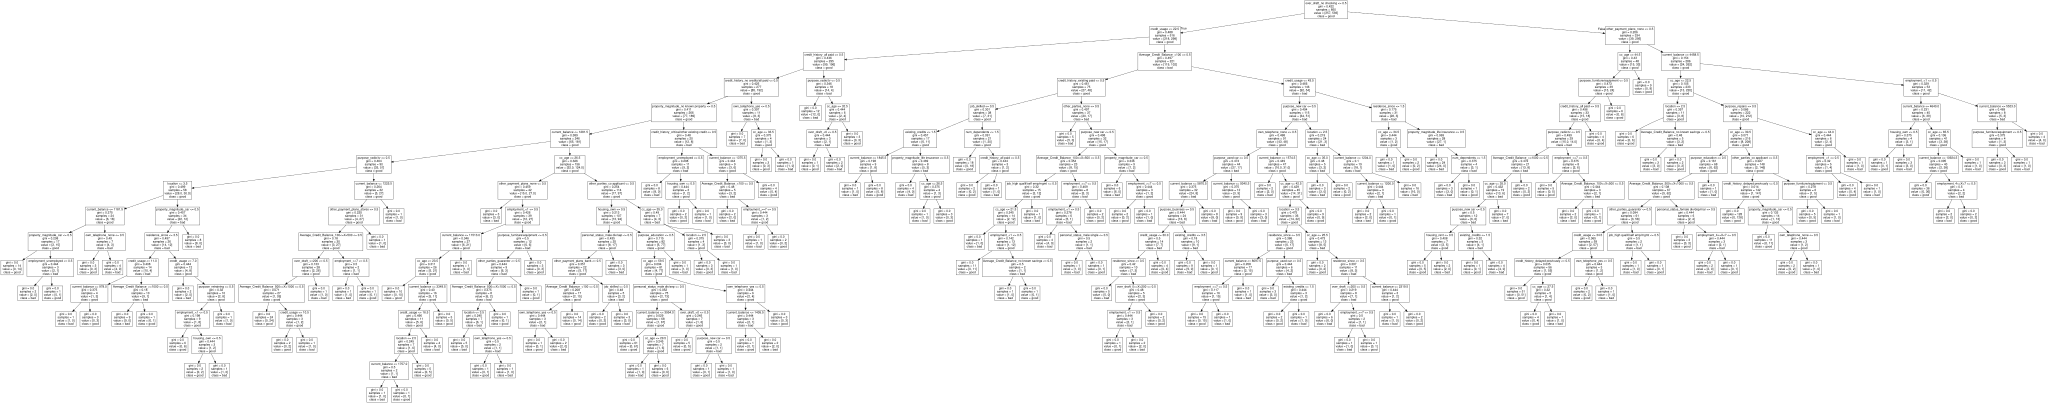

In [10]:
from sklearn.tree import export_graphviz
import graphviz
dot_data = export_graphviz(model, out_file=None,
                          feature_names=c_data_encoded.columns,
                          class_names=model.classes_,
                          )
graph = graphviz.Source(dot_data)
graph


In [11]:
train_accuracy = model.score(X_train,y_train)
print("Accuracy of the model on train data = ",train_accuracy)
test_accuracy = model.score(X_test,y_test)
print("Accuracy of the model on test data = ",test_accuracy)


Accuracy of the model on train data =  1.0
Accuracy of the model on test data =  0.6533333333333333


In [12]:
model1 = DecisionTreeClassifier(min_samples_split=10,min_impurity_decrease=0.005)
model1.fit(X_train,y_train)
print("train_accuracy = ", model1.score(X_train,y_train))
print("test_accuracy = ", model1.score(X_test,y_test))


train_accuracy =  0.7635294117647059
test_accuracy =  0.7266666666666667


In [14]:
model2 = DecisionTreeClassifier(min_samples_split=20,min_impurity_decrease=0.1)
model2.fit(X_train,y_train)
print("train_accuracy = ", model2.score(X_train,y_train))
print("test_accuracy = ", model2.score(X_test,y_test))

train_accuracy =  0.6976470588235294
test_accuracy =  0.7133333333333334
